## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D) 

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들) 
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

## 과제 수행 내용


- **데이터셋 변경**: STL10 (96x96 컬러, 10 클래스)
- **Batch Normalization**: 각 BasicBlock의 conv1, conv2 뒤에 추가
- **stride 변형**: BasicBlock의 conv2를 stride=2로 설정하여 다운샘플링 수행
- **Conv layer 추가**: 이미지 해상도(96x96)에 맞춰 BasicBlock 4개(96→48→24→12→6)
- **Residual Connection 추가**: 각 BasicBlock에 1x1 conv 기반 projection shortcut을 추가하여, conv1-conv2를 통과한 결과에 입력을 더해준 뒤 ReLU 적용
- **Global Average Pooling 추가**: FC layer 앞단에 GAP를 추가하여 (256, 6, 6) feature map을 (256, 1, 1)로 압축, FC 파라미터 수를 대폭 감소시켜 overfitting 방지
- **Data Augmentation**: RandomHorizontalFlip, RandomCrop, ColorJitter를 추가하여 적은 학습 데이터에 대한 regularization 효과 강화
- **Kaiming(He) 초기화**: `_init_weights()`에서 Conv2d, Linear, BatchNorm2d 가중치 초기화
- **Label Smoothing**: `CrossEntropyLoss(label_smoothing=0.1)`을 적용하여 모델이 정답에 과도하게 확신하지 않도록 regularization
- **Dropout**: FC layer에 Dropout(0.3) 추가
- **EarlyStopping**: validation set(train 90% / val 10%)을 분리하여 val_loss 기준으로 patience(7)만큼 개선이 없으면 학습 조기 종료

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

(3, 96, 96)


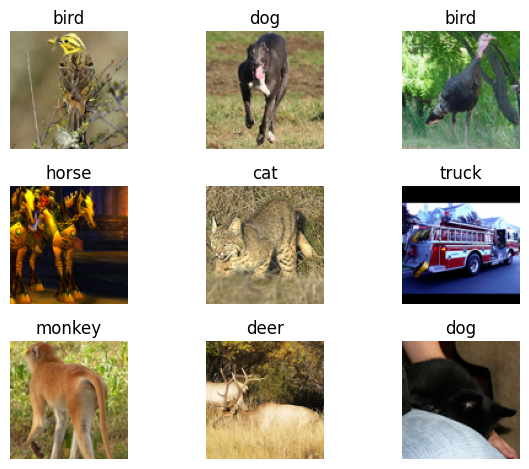

In [26]:
# 데이터셋 정의 

train_data = datasets.STL10(
    './data/',
    split='train',
    download=True,
    transform=transforms.Compose([
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomCrop(96, padding=8),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

test_data = datasets.STL10(
    root="./data/",
    split='test',
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

for i in range(9):
    plt.subplot(3, 3, i+1)
    # STL10은 (C,H,W) 순서로 저장되어 있어서 imshow용으로 축 순서 변경
    plt.imshow(train_data.data[i].transpose(1, 2, 0))
    plt.title(train_data.classes[train_data.labels[i]])
    plt.axis('off')

print(train_data.data[0].shape)  # (3, 96, 96)
plt.tight_layout()
plt.show()

In [27]:
# EarlyStopping을 위한 validation set 분리 (train 90% / val 10%)
from torch.utils.data import random_split

val_size = int(len(train_data) * 0.1)
train_size = len(train_data) - val_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

print(f"train: {len(train_subset)}, val: {len(val_subset)}, test: {len(test_data)}")

train: 4500, val: 500, test: 8000


## Modeling

In [46]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        # stride = 2로 하여 다운샘플링 수행 (maxpool 대체)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, stride = 2, padding=1)

        # BatchNorm 추가
        self.bn1 = nn.BatchNorm2d(hidden_dim)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()
        # Dropout 추가
        self.dropout = nn.Dropout2d(0.3)

        # residual connection 
        # 입력(in_channels, H, W)을 출력(out_channels, H/2, W/2)에 맞춰 채널 수/크기를 변형
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2)
        self.shortcut_bn = nn.BatchNorm2d(out_channels)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''
    
    def forward(self, x): 
        identity = self.shortcut_bn(self.shortcut(x))  # 원본을 출력 크기에 맞게 변형
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = x + identity # residual connection
        x = self.relu(x)
        return x

        # return self.model(x)

In [47]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()
        
        # CNN 블럭 정의
        # 블록을 4개로 하여 96 -> 48 -> 24 -> 12 -> 6으로 다운샘플링
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=64, hidden_dim=48)
        self.block3 = BasicBlock(in_channels=64, out_channels=128, hidden_dim=96)
        self.block4 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=192)
        
        # classification을 위한 FC 정의
        # (256, 6, 6) -> (256, 1, 1)로 압축 
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(in_features=256, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self._init_weights()

    def _init_weights(self):
        # Kaiming(He) 초기화
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) 
        x = self.block4(x) # 출력모양: (-1, 256, 6, 6)

        x = self.gap(x)
        x = torch.flatten(x, start_dim=1)
        
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [48]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: mps


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU()
    (dropout): Dropout2d(p=0.3, inplace=False)
    (shortcut): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
    (shortcut_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(48, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track

In [49]:
# Learning rate
lr = 1e-3

# Optimizer
optim = Adam(model.parameters(), lr=lr)

patience = 7
best_val_loss = float('inf')
counter = 0

# Train loop
for epoch in range(100):
    model.train()
    for data, label in tqdm(train_loader): # read data
        optim.zero_grad() # Iniitlaization
        
        preds = model(data.to(device)) # prediction
        
        # Loss Function
        loss = nn.CrossEntropyLoss(label_smoothing=0.1)(preds, label.to(device)) # label smoothing
        loss.backward()
        optim.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, label in val_loader:
            preds = model(data.to(device))
            val_loss += nn.CrossEntropyLoss()(preds, label.to(device)).item() * data.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch{epoch+1} train_loss:{loss.item():.4f} val_loss:{val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "STL10.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

100%|██████████| 141/141 [00:09<00:00, 15.04it/s]


epoch1 train_loss:1.7402 val_loss:1.7125


100%|██████████| 141/141 [00:09<00:00, 15.48it/s]


epoch2 train_loss:1.8288 val_loss:1.6687


100%|██████████| 141/141 [00:09<00:00, 15.48it/s]


...

epoch44 train_loss:0.9624 val_loss:0.8264


100%|██████████| 141/141 [00:10<00:00, 12.95it/s]


epoch45 train_loss:0.9145 val_loss:0.7906


100%|██████████| 141/141 [00:10<00:00, 12.95it/s]


epoch46 train_loss:0.8243 val_loss:0.8484
Early stopping at epoch 46


In [50]:
model.load_state_dict(torch.load("STL10.pth", map_location=device))

num_corr = 0
model.eval()
with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 250/250 [00:06<00:00, 36.81it/s]

Accuracy:0.742625
